# Chapter 1. 수학적 모델링, 수치해법과 문제풀이

### 자유낙하하는 물체의 운동방정식

낙하 방향을 양의 방향으로 정의한다.

낙하하는 사람에게 작용하는 힘은 중력과 공기저항이다.

중력은 아래 방향으로

$$
F_g = mg
$$

이고, 공기저항은 운동 반대 방향으로

$$
F_D = cv^2
$$

이다.

따라서 Newton의 제2법칙을 적용하면

$$
m\frac{dv}{dt}
=
mg-cv^2
$$

가 된다.

이를 정리하면

$$
\boxed{
\frac{dv}{dt}
=
g-\frac{c}{m}v^2
}
$$

이다.

초기에는 열기구가 정지해 있고 사람이 정지 상태에서 낙하를 시작하므로 초기조건은

$$
\boxed{
v(0)=0
}
$$

이다.

---

### 미분방정식의 해석해

운동방정식
$$ \frac{dv}{dt} = g-\frac{c}{m}v^2 $$
을 변수분리하면
$$ \frac{dv} {g-\dfrac{c}{m}v^2} = dt $$
가 된다.

여기서 종단속도 $v_t$를 $ v_t = \sqrt{\frac{mg}{c}} $ 라고 정의하면
$ \frac{c}{m} = \frac{g}{v_t^2} $ 이므로 운동방정식은

$$
\frac{dv}{dt} = g \left( 1-\frac{v^2}{v_t^2} \right)
$$

으로 표현할 수 있다.

따라서

$$ \frac{dv} {1-\dfrac{v^2}{v_t^2}} = g\,dt $$

이다.

양변을 적분하면

$$ v_t \tanh^{-1} \left( \frac{v}{v_t} \right) = gt+C $$

를 얻는다.

초기조건 $ v(0)=0 $ 을 적용하면 $ C=0 $ 이므로

$$ \tanh^{-1} \left( \frac{v}{v_t} \right) = \frac{gt}{v_t} $$

가 된다.

따라서 최종적인 속도의 해석해는

$$ \boxed{ v(t) = v_t \tanh \left( \frac{gt}{v_t} \right) } $$

이다.

또는 $v_t=\sqrt{mg/c}$를 직접 대입하면

$$ \boxed{ v(t) = \sqrt{\frac{mg}{c}} \tanh \left( \sqrt{\frac{gc}{m}}\,t \right) } $$

로 표현할 수 있다.


### 종단속도

종단속도는 더 이상 가속되지 않는 상태, 즉 $ \frac{dv}{dt}=0 $ 일 때의 속도이다.

운동방정식에서 $ mg-cv_t^2=0 $ 이므로 $ cv_t^2=mg $ 이다.

따라서 종단속도는 
$$ \boxed{ v_t=\sqrt{\frac{mg}{c}} } $$
이다.

주어진 값을 대입하면
$$ v_t = \sqrt{ \frac{ (68.1)(9.81) }{ 0.25 } } $$
이고,

$$ \boxed{ v_t \approx 51.69\ \mathrm{m/s} } $$
이다.

즉, 줄의 길이를 무한히 길다고 가정하면 낙하 속도는 계속 증가하는 것이 아니라 약 $51.7\ \mathrm{m/s}$에 점근적으로 접근한다.|

- 예제 1.1: 번지점프 문제에 대한 해석해

---

질량이 $68.1\ \mathrm{kg}$인 번지점프하는 사람이 정지해 있는 열기구에서 낙하한다고 가정한다.
낙하하는 동안 공기저항은 속도의 제곱에 비례하며, 항력계수는 $c = 0.25\ \mathrm{kg/m}$ 이다.
중력가속도는 $g = 9.81\ \mathrm{m/s^2}$로 사용한다.
번지점프 줄의 길이가 무한히 길다고 가정하여 줄에 의한 힘은 고려하지 않는다.

---

Terminal velocity = 51.694 m/s
Velocity at t = 12 s = 50.617 m/s


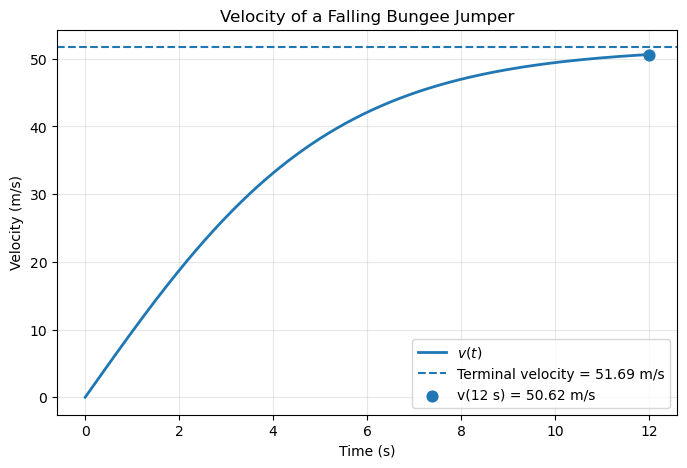

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# Parameters
# --------------------------------------------------

m = 68.1       # mass [kg]
g = 9.81       # gravitational acceleration [m/s^2]
c = 0.25       # drag coefficient [kg/m]

# --------------------------------------------------
# Terminal velocity
# --------------------------------------------------

v_terminal = np.sqrt(m * g / c)

print(f"Terminal velocity = {v_terminal:.3f} m/s")

# --------------------------------------------------
# Analytical solution
# v(t) = vt * tanh(g*t/vt)
# --------------------------------------------------

def velocity(t):
    return v_terminal * np.tanh(g * t / v_terminal)


# velocity at t = 12 s
v_12 = velocity(12.0)

print(f"Velocity at t = 12 s = {v_12:.3f} m/s")

# --------------------------------------------------
# Calculate velocity from 0 to 12 s
# --------------------------------------------------

t = np.linspace(0, 12, 500)
v = velocity(t)

# --------------------------------------------------
# Plot
# --------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(t, v, linewidth=2, label=r"$v(t)$")
plt.axhline(
    v_terminal,
    linestyle="--",
    label=f"Terminal velocity = {v_terminal:.2f} m/s"
)

plt.scatter(
    12,
    v_12,
    s=60,
    zorder=3,
    label=f"v(12 s) = {v_12:.2f} m/s"
)

plt.xlabel("Time (s)")
plt.ylabel("Velocity (m/s)")
plt.title("Velocity of a Falling Bungee Jumper")
plt.grid(True, alpha=0.3)
plt.legend()

plt.show()

# Chapter 4. 반올림오차와 절단오차

- 예제 4.1: 반복법에서 오차 추정

$$
e^x = 1+x+\frac{x^2}{2}+\frac{x^3}{3!}+\cdots + \frac{x^n}{n!}
$$

In [14]:
import math

# 계산할 값
x = 0.5

# 참값
true_value = math.exp(x)

# 초기값
approx = 0.0
previous_approx = None

results = []

# Maclaurin 급수의 처음 6개 항
for n in range(6):

    # 새로운 항
    term = x**n / math.factorial(n)

    # 부분합
    approx += term

    # 참 백분율 상대오차
    true_error = abs(
        (true_value - approx) / true_value
    ) * 100

    # 근사 백분율 상대오차
    if previous_approx is None:
        approx_error = None
    else:
        approx_error = abs(
            (approx - previous_approx) / approx
        ) * 100

    results.append([
        n + 1,
        approx,
        true_error,
        approx_error
    ])

    previous_approx = approx


# --------------------------------------------------
# 결과 출력
# --------------------------------------------------

print(f"True value: e^0.5 = {true_value:.10f}\n")

# 열 제목
print(
    f"{'Terms':>8}"
    f"{'Approximation':>18}"
    f"{'True Error (%)':>20}"
    f"{'Approx. Error (%)':>22}"
)

# 구분선
print("-" * 68)

# 계산 결과
for terms, approx, true_error, approx_error in results:

    if approx_error is None:
        approx_error_str = "-"
    else:
        approx_error_str = f"{approx_error:.8f}"

    print(
        f"{terms:>8d}"
        f"{approx:>18.8f}"
        f"{true_error:>20.8f}"
        f"{approx_error_str:>22}"
    )

True value: e^0.5 = 1.6487212707

   Terms     Approximation      True Error (%)     Approx. Error (%)
--------------------------------------------------------------------
       1        1.00000000         39.34693403                     -
       2        1.50000000          9.02040104           33.33333333
       3        1.62500000          1.43876780            7.69230769
       4        1.64583333          0.17516226            1.26582278
       5        1.64843750          0.01721156            0.15797788
       6        1.64869792          0.00141649            0.01579529


---

- 파이썬 코드에서 반올림 오차 예

In [2]:
1.1 + 0.1 == 1.2

False

In [3]:
1.1 + 0.1 > 1.2

True

In [4]:
a = 1.1 + 0.1
b = 1.2

print(a)  # 1.2000000000000002 와 같은 값이 출력될 수 있음
print(b)

# 부동소수점 표현을 확인하려면 repr()을 사용     # repre(): string representation of the object
print(repr(a))  # 출력: '1.2000000000000002'
print(repr(b))  # 출력: '1.2'

# 비교
print(a == b)  # False


1.2000000000000002
1.2
1.2000000000000002
1.2
False


In [ ]:
# 수학적으로 같은지를 확인하려면 math.isclose()를 사용
import math
print(math.isclose(a, b))  # True

True


- 파이썬 코드에서 배정도 실수의 최댓값 확인하기

In [6]:
import sys

max_float = sys.float_info.max
min_float = sys.float_info.min

print("배정도 실수 중 가장 큰 값:", max_float)
print("배정도 실수 중 가장 작은 값:", min_float)

배정도 실수 중 가장 큰 값: 1.7976931348623157e+308
배정도 실수 중 가장 작은 값: 2.2250738585072014e-308


- 파이썬 코드에서 기계입실론 확인하기

In [7]:
import sys

# 기계입실론 (machine epsilon) 확인
epsilon = sys.float_info.epsilon

print("기계입실론:", epsilon)

기계입실론: 2.220446049250313e-16


- 기계엡실론 계산하기

In [8]:
# 정확한 정의에 의한 방법
def machineEpsilon(func=float):
    machine_epsilon = func(1)     # func는 기본적으로 float, float(1)은 1.0
    while func(1) + machine_epsilon != func(1):
        machine_epsilon_last = machine_epsilon
        machine_epsilon = func(machine_epsilon) / func(2)
    return machine_epsilon_last

print(machineEpsilon())

2.220446049250313e-16


In [10]:
print(machineEpsilon(np.float32))  # float32에 대한 기계입실론
print(machineEpsilon(np.float64))  # float64에 대한 기계입실론

1.1920929e-07
2.220446049250313e-16


In [11]:
# 근사적 방법
epsilon = 1.0
while (1.0 + 0.5 * epsilon) != 1.0:
    epsilon = 0.5 * epsilon

print(epsilon)

2.220446049250313e-16


- 뺄셈의 무효화

In [12]:
import math

a = 1
b = 30000000.0000001
c = 3

# 근의 공식 계산
discriminant = b**2 - 4*a*c  # 판별식

# 뺄셈의 무효화가 발생하는 부분을 출력
print("b^2 - 4ac (판별식):", discriminant)
print("sqrt(b^2 - 4ac):", math.sqrt(discriminant))
print("b :", b)
print("")

# 두 근을 계산 (양의 근과 음의 근)
root1 = (-b + math.sqrt(discriminant)) / (2*a)
root2 = (-b - math.sqrt(discriminant)) / (2*a)

print("근1:", root1)
print("근2:", root2)


b^2 - 4ac (판별식): 899999999999994.0
sqrt(b^2 - 4ac): 29999999.9999999
b : 30000000.0000001

근1: -1.0058283805847168e-07
근2: -30000000.0


- 테일러 급수전개의 나머지 항

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq

import sympy as sp

import ipywidgets as widgets
from IPython.display import display, clear_output


# ============================================================
# 1. Symbolic variable
# ============================================================

x_sym = sp.symbols("x")


# ============================================================
# 2. Function string -> numerical function + derivative
# ============================================================

def make_function(function_string):
    """
    사용자가 입력한 함수 문자열을 SymPy expression으로 변환하고,
    함수와 도함수를 numerical function으로 반환
    """

    # 문자열을 symbolic expression으로 변환
    expr = sp.sympify(function_string)

    # derivative
    derivative_expr = sp.diff(expr, x_sym)

    # numpy에서 계산할 수 있는 함수로 변환
    f = sp.lambdify(x_sym, expr, modules=["numpy"])
    df = sp.lambdify(x_sym, derivative_expr, modules=["numpy"])

    return expr, derivative_expr, f, df


# ============================================================
# 3. Mean Value Theorem point c 찾기
#
#       f'(c) = [f(b)-f(a)] / (b-a)
#
# ============================================================

def find_c(f, df, a, b):

    # secant slope
    m_secant = (f(b) - f(a)) / (b - a)

    # 해결해야 하는 방정식
    def equation(x):
        return df(x) - m_secant

    # interval sampling
    xs = np.linspace(a, b, 1000)

    try:
        values = equation(xs)

        # 상수 derivative 등에 대응
        values = np.asarray(values)

        if values.ndim == 0:
            values = np.full_like(xs, values, dtype=float)

    except:
        return np.array([])

    roots = []

    for i in range(len(xs) - 1):

        y1 = values[i]
        y2 = values[i + 1]

        # NaN 또는 inf 무시
        if not np.isfinite(y1) or not np.isfinite(y2):
            continue

        # 거의 0인 경우
        if abs(y1) < 1e-8:
            roots.append(xs[i])

        # sign change
        elif y1 * y2 < 0:

            try:

                root = brentq(
                    equation,
                    xs[i],
                    xs[i + 1]
                )

                roots.append(root)

            except:
                pass


    if len(roots) == 0:
        return np.array([])


    # 중복 root 제거
    roots = np.unique(
        np.round(roots, 10)
    )

    # endpoint 제외
    roots = roots[
        (roots > a + 1e-6)
        &
        (roots < b - 1e-6)
    ]

    return roots


# ============================================================
# 4. Plot function
# ============================================================

def plot_mvt(
    function_string,
    a,
    b,
    xmin,
    xmax
):

    # --------------------------------------------------------
    # a < b 확인
    # --------------------------------------------------------

    if a >= b:

        print("a must be smaller than b.")

        return


    # --------------------------------------------------------
    # x plotting range 확인
    # --------------------------------------------------------

    if xmin >= xmax:

        print("xmin must be smaller than xmax.")

        return


    # --------------------------------------------------------
    # 함수 생성
    # --------------------------------------------------------

    try:

        expr, derivative_expr, f, df = make_function(
            function_string
        )

    except Exception as e:

        print("Function input error:")
        print(e)

        return


    # --------------------------------------------------------
    # 함수값 계산
    # --------------------------------------------------------

    try:

        fa = float(f(a))
        fb = float(f(b))

    except Exception:

        print("The function cannot be evaluated at a or b.")

        return


    if not np.isfinite(fa) or not np.isfinite(fb):

        print("f(a) or f(b) is not finite.")

        return


    # --------------------------------------------------------
    # Secant slope
    # --------------------------------------------------------

    m_secant = (
        fb - fa
    ) / (
        b - a
    )


    # --------------------------------------------------------
    # Mean Value Theorem point
    # --------------------------------------------------------

    roots = find_c(
        f,
        df,
        a,
        b
    )


    # --------------------------------------------------------
    # Plot range
    # --------------------------------------------------------

    x = np.linspace(
        xmin,
        xmax,
        1500
    )


    try:

        y = f(x)

        # constant function 대응
        y = np.asarray(y)

        if y.ndim == 0:
            y = np.full_like(
                x,
                float(y),
                dtype=float
            )

    except Exception:

        print("Could not evaluate the function over the plotting range.")

        return


    # ========================================================
    # Figure
    # ========================================================

    fig, ax = plt.subplots(
        figsize=(11, 6.5)
    )


    # --------------------------------------------------------
    # Function
    # --------------------------------------------------------

    ax.plot(
        x,
        y,
        linewidth=2.5,
        label=r"$f(x)$"
    )


    # --------------------------------------------------------
    # a and b
    # --------------------------------------------------------

    ax.scatter(
        [a, b],
        [fa, fb],
        s=90,
        zorder=5
    )


    ax.annotate(
        "a",
        (a, fa),
        xytext=(0, 12),
        textcoords="offset points",
        ha="center",
        fontsize=12
    )


    ax.annotate(
        "b",
        (b, fb),
        xytext=(0, 12),
        textcoords="offset points",
        ha="center",
        fontsize=12
    )


    # --------------------------------------------------------
    # Secant line
    #
    # y = f(a) + m(x-a)
    # --------------------------------------------------------

    secant_line = (
        fa
        +
        m_secant * (x - a)
    )


    ax.plot(
        x,
        secant_line,
        "--",
        linewidth=2,
        label="Secant line"
    )


    # ========================================================
    # Mean Value Theorem point c
    # ========================================================

    if len(roots) > 0:

        # 여러 solution이 있을 경우 첫 번째 사용
        c = roots[0]

        fc = float(f(c))
        m_tangent = float(df(c))


        # tangent
        tangent_line = (
            fc
            +
            m_tangent * (x - c)
        )


        ax.plot(
            x,
            tangent_line,
            linewidth=2,
            label="Tangent at c"
        )


        ax.scatter(
            c,
            fc,
            s=110,
            zorder=6
        )


        ax.annotate(
            "c",
            (c, fc),
            xytext=(0, 14),
            textcoords="offset points",
            ha="center",
            fontsize=13
        )


        ax.axvline(
            c,
            linestyle=":",
            alpha=0.5
        )


        # ----------------------------------------------------
        # numerical information
        # ----------------------------------------------------

        text = (
            rf"$a={a:.3f}$" "\n"
            rf"$b={b:.3f}$" "\n"
            rf"$c={c:.4f}$" "\n\n"
            rf"Secant slope $={m_secant:.4f}$" "\n"
            rf"$f'(c)={m_tangent:.4f}$"
        )


        ax.text(
            0.03,
            0.97,
            text,
            transform=ax.transAxes,
            verticalalignment="top",
            fontsize=11,
            bbox=dict(
                boxstyle="round",
                alpha=0.15
            )
        )


    else:

        ax.text(
            0.03,
            0.97,
            "No interior point c was numerically detected.",
            transform=ax.transAxes,
            verticalalignment="top",
            fontsize=11
        )


    # --------------------------------------------------------
    # title
    # --------------------------------------------------------

    title = (
        "Mean Value Theorem\n"
        +
        f"f(x) = {sp.sstr(expr)}"
        +
        "\n"
        +
        f"f'(x) = {sp.sstr(derivative_expr)}"
    )


    ax.set_title(
        title,
        fontsize=14
    )


    # --------------------------------------------------------
    # axis
    # --------------------------------------------------------

    ax.axhline(
        0,
        linewidth=0.8
    )

    ax.axvline(
        0,
        linewidth=0.8
    )


    ax.set_xlim(
        xmin,
        xmax
    )


    ax.set_xlabel(
        "x",
        fontsize=12
    )

    ax.set_ylabel(
        "f(x)",
        fontsize=12
    )


    ax.legend()

    ax.grid(
        alpha=0.25
    )


    plt.show()


# ============================================================
# 5. Widgets
# ============================================================

function_input = widgets.Text(
    value="0.12*x**3 - 0.6*x**2 + 0.5*x + 2",
    description="f(x):",
    layout=widgets.Layout(
        width="600px"
    )
)


a_slider = widgets.FloatSlider(
    value=-2.0,
    min=-5.0,
    max=5.0,
    step=0.1,
    description="a",
    continuous_update=True
)


b_slider = widgets.FloatSlider(
    value=4.0,
    min=-5.0,
    max=5.0,
    step=0.1,
    description="b",
    continuous_update=True
)


xmin_slider = widgets.FloatSlider(
    value=-4.0,
    min=-10.0,
    max=0.0,
    step=0.5,
    description="xmin",
    continuous_update=True
)


xmax_slider = widgets.FloatSlider(
    value=6.0,
    min=0.0,
    max=10.0,
    step=0.5,
    description="xmax",
    continuous_update=True
)


# ============================================================
# 6. Interactive output
# ============================================================

interactive_plot = widgets.interactive(
    plot_mvt,

    function_string=function_input,

    a=a_slider,
    b=b_slider,

    xmin=xmin_slider,
    xmax=xmax_slider
)


display(interactive_plot)

interactive(children=(Text(value='0.12*x**3 - 0.6*x**2 + 0.5*x + 2', description='f(x):', layout=Layout(width=…